In [1]:
!pip install openpyxl scikit-learn pandas numpy matplotlib seaborn scipy -q

import os, pickle, warnings, json
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
from scipy.stats import ks_2samp

import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import matplotlib.ticker  as ticker
import seaborn            as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition  import PCA

pd.set_option('display.max_columns',  60)
pd.set_option('display.max_rows',     100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.width',        220)

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'figure.dpi'       : 120,
})

LAYER_COLORS = {
    'physical'    : '#2196F3',
    'network'     : '#FF9800',
    'control'     : '#4CAF50',
    'supervisory' : '#9C27B0',
    'process'     : '#F44336',
}

NORMAL_PATH = '/kaggle/input/datasets/jaytalwar2005/swat-dataset-ctmas/SWaT_Dataset_Normal_v1.xlsx'
ATTACK_PATH = '/kaggle/input/datasets/jaytalwar2005/swat-dataset-ctmas/SWaT_Dataset_Attack_v0.xlsx'
OUT         = '/kaggle/working'

for d in [f'{OUT}/figures', f'{OUT}/processed']:
    os.makedirs(d, exist_ok=True)

for path, name in [(NORMAL_PATH, 'Normal XLSX'),
                   (ATTACK_PATH, 'Attack XLSX')]:
    exists  = os.path.exists(path)
    size_mb = os.path.getsize(path) / 1024**2 if exists else 0
    status  = 'Yes' if exists else 'NO NOT FOUND'
    print(f'{status}  {name:<15}  {size_mb:>8.1f} MB')

print('\nPhase 1 setup complete')

Yes  Normal XLSX         124.5 MB
Yes  Attack XLSX         110.6 MB

Phase 1 setup complete


In [2]:
# Both files are Excel — use read_excel for both

def load_excel(path, label):
    print(f'Loading {label}...')
    # Try sheet names in order — SWaT files use different sheet names
    for sheet in ['Normal', 'Attack Data', 'Combined Data',
                  'Sheet1', 0]:
        try:
            df = pd.read_excel(path, sheet_name=sheet,
                               skiprows=1, engine='openpyxl')
            df['source'] = label
            print(f'   Sheet   : "{sheet}"')
            print(f'   Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols')
            print(f'   Columns : {list(df.columns)}')
            return df
        except Exception:
            continue
    raise ValueError(f'Could not load {path} — no valid sheet found')

print('=' * 55)
df_normal = load_excel(NORMAL_PATH, 'normal_file')
print()
df_attack  = load_excel(ATTACK_PATH,  'attack_file')
print('=' * 55)

Loading normal_file...
   Sheet   : "0"
   Shape   : 495,000 rows × 54 cols
   Columns : [' Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack', 'source']

Loading attack_file...
   Sheet   : "Combined Data"
   Shape   : 449,919 rows × 54 cols
   Columns : [' Timestamp', 'FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402'

In [3]:
# Strip whitespace from column names
df_normal.columns = df_normal.columns.str.strip()
df_attack.columns  = df_attack.columns.str.strip()

print('Normal columns :', list(df_normal.columns))
print('Attack columns :', list(df_attack.columns))

# Standardise label column name
for df_ in [df_normal, df_attack]:
    for old in ['Normal/Attack', 'label', 'Label',
                'Attack', 'attack', 'class', 'Class']:
        if old in df_.columns:
            df_.rename(columns={old: 'label'}, inplace=True)
            break

# Merge
df = pd.concat([df_normal, df_attack], ignore_index=True)

# Clean label strings
df['label'] = (df['label']
               .astype(str)
               .str.strip()
               .str.lower()
               .str.replace(r'\s+', ' ', regex=True))

print(f'\nUnique label values : {df["label"].unique()}')

# Binary label: 0 = normal, 1 = attack
df['binary_label'] = df['label'].apply(
    lambda x: 0 if str(x).strip() == 'normal' else 1
)

# Parse timestamp
TIME_COL = None
for c in df.columns:
    if any(k in c.lower() for k in ['time', 'date', 'stamp']):
        TIME_COL = c
        break

if TIME_COL:
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
    df = df.sort_values(TIME_COL).reset_index(drop=True)
    print(f' Timestamp : {TIME_COL}')
    print(f'  Range     : {df[TIME_COL].min()} → {df[TIME_COL].max()}')

# Sensor columns = everything except metadata
EXCLUDE     = {'label', 'binary_label', 'source'}
if TIME_COL:
    EXCLUDE.add(TIME_COL)
SENSOR_COLS = [c for c in df.columns if c not in EXCLUDE]

# Coerce all sensors to numeric
for c in SENSOR_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Fill NaN
df[SENSOR_COLS] = (df[SENSOR_COLS]
                   .fillna(method='ffill')
                   .fillna(method='bfill')
                   .fillna(0))
print("\n")

print(f'  Combined shape   : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Normal samples   : {(df["binary_label"]==0).sum():,}')
print(f'  Attack samples   : {(df["binary_label"]==1).sum():,}')
print(f'  Attack ratio     : {df["binary_label"].mean()*100:.2f}%')
print(f'  Sensor columns   : {len(SENSOR_COLS)}')
print(f'  NaN remaining    : {df[SENSOR_COLS].isna().sum().sum()}')
print("\n")
print(f'\nAll sensor columns:\n{SENSOR_COLS}')

Normal columns : ['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack', 'source']
Attack columns : ['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P6

In [4]:
def keep(cols):
    return [c for c in cols if c in df.columns]

LAYER_MAP = {

    # LAYER 1 — PHYSICAL
    # Direct sensor readings: flow, level, pressure, quality
    # Most attacked layer — sensor spoofing, false data injection
    'physical': keep([
        'FIT101', 'LIT101',                          # P1 raw water
        'AIT201', 'AIT202', 'AIT203', 'FIT201',     # P2 dosing
        'DPIT301', 'FIT301', 'LIT301',               # P3 UF
        'AIT401', 'AIT402', 'FIT401', 'LIT401',     # P4 RO
        'AIT501', 'AIT502', 'AIT503', 'AIT504',     # P5 storage quality
        'FIT501', 'FIT502', 'FIT503', 'FIT504',     # P5 storage flow
        'PIT501', 'PIT502', 'PIT503',               # P5 pressure
        'FIT601',                                    # P6 recycle
    ]),

    # LAYER 2 — NETWORK
    # Inter-PLC communication boundary sensors
    # Replay attacks and MitM attacks show as timing anomalies
    'network': keep([
        'FIT101',   # PLC1→PLC2 handoff
        'FIT201',   # PLC2→PLC3 handoff
        'FIT301',   # PLC3→PLC4 handoff
        'FIT401',   # PLC4→PLC5 handoff
        'FIT501',   # PLC5→PLC6 handoff
        'FIT601',   # PLC6→Historian
        'LIT101',   # Cross-PLC level consistency
        'LIT301',   # Cross-PLC level consistency
        'LIT401',   # Cross-PLC level consistency
    ]),

    # LAYER 3 — CONTROL
    # Actuator command outputs — what the PLC decides to DO
    # Where the AI control loop operates
    # Command injection, actuator manipulation
    'control': keep([
        'MV101', 'P101', 'P102',                    # P1
        'MV201', 'P201', 'P202', 'P203',            # P2
        'P204', 'P205', 'P206',                     # P2
        'MV301', 'MV302', 'MV303', 'MV304',         # P3
        'P301', 'P302',                              # P3
        'P401', 'P402', 'P403', 'P404', 'UV401',    # P4
        'P501', 'P502',                              # P5
        'P601', 'P602', 'P603',                     # P6
    ]),

    # LAYER 4 — SUPERVISORY
    # SCADA/HMI level — setpoints and alarm references
    # HMI manipulation, historian falsification
    'supervisory': keep([
        'LIT101', 'LIT301', 'LIT401',               # Tank level setpoints
        'FIT101', 'FIT201', 'FIT301',               # Flow references
        'FIT401', 'FIT501',                          # Flow references
        'DPIT301',                                   # UF pressure alarm
        'PIT501', 'PIT502', 'PIT503',               # RO pressure alarms
        'AIT201', 'AIT402', 'AIT501',               # Quality alarms
    ]),

    # LAYER 5 — PROCESS
    # Cross-stage physics: mass balance and conservation laws
    # Stealthy coordinated attacks that violate physical invariants
    'process': keep([
        'FIT101', 'FIT201', 'FIT301',               # Flow chain
        'FIT401', 'FIT501', 'FIT502',               # Flow chain
        'FIT503', 'FIT504', 'FIT601',               # Flow chain + recycle
        'LIT101', 'LIT301', 'LIT401',               # Storage levels dV/dt
        'AIT201', 'AIT401', 'AIT501',               # Quality invariants
        'DPIT301', 'PIT501',                         # Pressure invariants
    ]),
}

# Remove duplicates within each layer
for layer in LAYER_MAP:
    LAYER_MAP[layer] = list(dict.fromkeys(LAYER_MAP[layer]))

# Verification
print('=' * 65)
print('  5-LAYER FEATURE MAP — VERIFICATION')
print('=' * 65)
all_ok = True
for layer, cols in LAYER_MAP.items():
    status = 'Yes' if cols else 'No EMPTY'
    print(f'\n{status}  {layer.upper()} LAYER  ({len(cols)} features)')
    for c in cols:
        print(f'       {c}')
    if not cols:
        all_ok = False

print("\n")
print(f'  Layers populated : {sum(1 for v in LAYER_MAP.values() if v)} / 5')
print(f'  All layers OK    : {"YES" if all_ok else "NO — check above"}')

with open(f'{OUT}/processed/layer_map.json', 'w') as f:
    json.dump(LAYER_MAP, f, indent=2)
print(f' layer_map.json saved')

  5-LAYER FEATURE MAP — VERIFICATION

Yes  PHYSICAL LAYER  (25 features)
       FIT101
       LIT101
       AIT201
       AIT202
       AIT203
       FIT201
       DPIT301
       FIT301
       LIT301
       AIT401
       AIT402
       FIT401
       LIT401
       AIT501
       AIT502
       AIT503
       AIT504
       FIT501
       FIT502
       FIT503
       FIT504
       PIT501
       PIT502
       PIT503
       FIT601

Yes  NETWORK LAYER  (9 features)
       FIT101
       FIT201
       FIT301
       FIT401
       FIT501
       FIT601
       LIT101
       LIT301
       LIT401

Yes  CONTROL LAYER  (26 features)
       MV101
       P101
       P102
       MV201
       P201
       P202
       P203
       P204
       P205
       P206
       MV301
       MV302
       MV303
       MV304
       P301
       P302
       P401
       P402
       P403
       P404
       UV401
       P501
       P502
       P601
       P602
       P603

Yes  SUPERVISORY LAYER  (15 features)
       LIT101
       LI

In [5]:
layer_stats = {}


print('  PER-LAYER STATISTICAL SUMMARY')


for layer, feats in LAYER_MAP.items():
    if not feats:
        continue

    unique = list(dict.fromkeys(feats))
    norm_  = df[df['binary_label'] == 0][unique]
    atk_   = df[df['binary_label'] == 1][unique]

    if len(atk_) < 10:
        print(f'\n⚠  {layer}: insufficient attack rows, skipping')
        continue

    stats_df = pd.DataFrame({
        'mean_normal' : norm_.mean(),
        'std_normal'  : norm_.std(),
        'mean_attack' : atk_.mean(),
        'std_attack'  : atk_.std(),
    })
    stats_df['shift_abs'] = (
        stats_df['mean_attack'] - stats_df['mean_normal']).abs()
    stats_df['shift_pct'] = (
        stats_df['shift_abs'] /
        (stats_df['mean_normal'].abs() + 1e-9) * 100)

    ks_rows = {}
    for col in unique:
        nv = norm_[col].dropna().values
        av = atk_[col].dropna().values
        if len(nv) > 20 and len(av) > 20:
            stat, pval = ks_2samp(nv, av)
            ks_rows[col] = {'ks_stat': round(stat, 4),
                            'ks_pval': round(pval, 6)}
    if ks_rows:
        stats_df = stats_df.join(pd.DataFrame(ks_rows).T)

    stats_df           = stats_df.sort_values('shift_abs', ascending=False)
    layer_stats[layer] = stats_df

    print(f'\n── {layer.upper()} LAYER ({len(unique)} features) ──────────')
    show = ['mean_normal', 'mean_attack', 'shift_pct', 'ks_stat', 'ks_pval']
    show = [c for c in show if c in stats_df.columns]
    print(stats_df[show].round(4).to_string())

print('\n Statistics complete')

  PER-LAYER STATISTICAL SUMMARY

── PHYSICAL LAYER (25 features) ──────────
         mean_normal  mean_attack  shift_pct  ks_stat  ks_pval
LIT401      881.5435     497.8791    43.5219   0.6172   0.0000
PIT501      250.7720     106.7178    57.4443   0.6284   0.0000
LIT101      588.7986     727.4178    23.5427   0.5723   0.0000
PIT503      189.6317      78.5080    58.5997   0.6283   0.0000
AIT402      161.7123     250.7772    55.0761   0.5829   0.0000
LIT301      901.0475     964.9589     7.0930   0.6040   0.0000
AIT201      240.5304     202.2273    15.9245   0.5694   0.0000
AIT502      151.5529     188.2998    24.2469   0.5719   0.0000
AIT401      135.4126     148.8069     9.8915   0.2779   0.0000
DPIT301      16.7147       8.4121    49.6722   0.5989   0.0000
AIT504       13.0285      16.6212    27.5757   0.6081   0.0000
AIT203      334.8798     337.1353     0.6735   0.3439   0.0000
FIT301        1.8468       0.6630    64.0993   0.5464   0.0000
FIT201        1.8380       0.6892    62.50

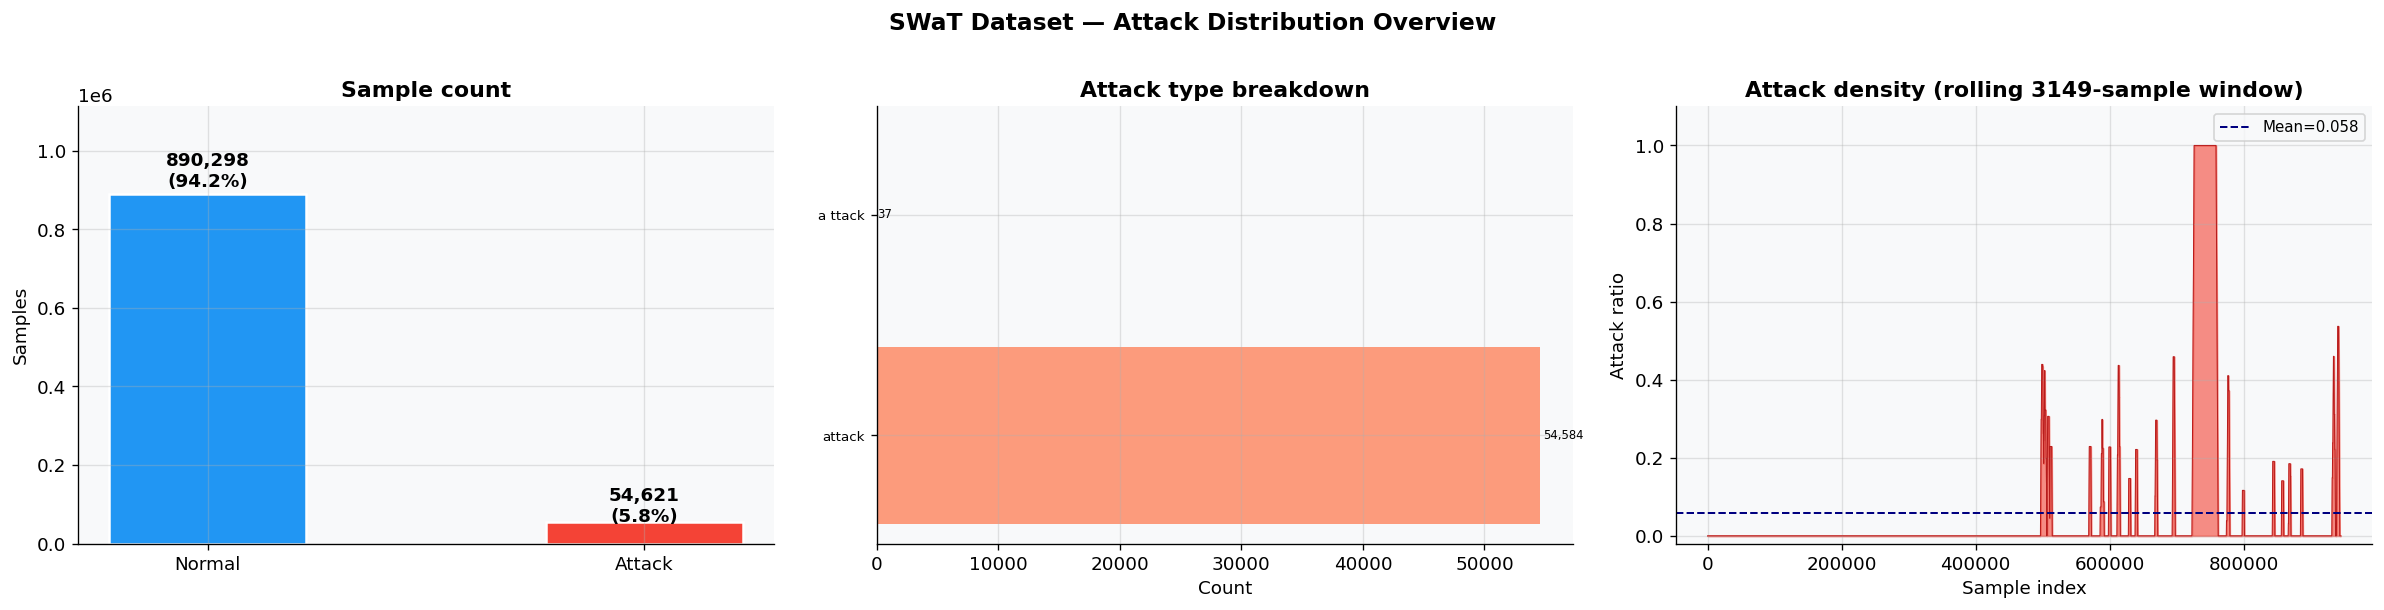

Saved: 01_attack_distribution.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('SWaT Dataset — Attack Distribution Overview',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: counts
counts = df['binary_label'].value_counts().sort_index()
bars   = axes[0].bar(['Normal', 'Attack'], counts.values,
                      color=['#2196F3', '#F44336'],
                      edgecolor='white', linewidth=1.5, width=0.45)
axes[0].set_title('Sample count', fontweight='bold')
axes[0].set_ylabel('Samples')
axes[0].set_ylim(0, counts.max() * 1.25)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Panel 2: attack type breakdown
atk_types  = df[df['binary_label']==1]['label'].value_counts().head(15)
colors_bar = plt.cm.Reds(np.linspace(0.35, 0.9, len(atk_types)))
axes[1].barh(range(len(atk_types)), atk_types.values, color=colors_bar)
axes[1].set_yticks(range(len(atk_types)))
axes[1].set_yticklabels([str(x)[:35] for x in atk_types.index], fontsize=8)
axes[1].set_title('Attack type breakdown', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(atk_types.values):
    axes[1].text(v*1.005, i, f'{v:,}', va='center', fontsize=7)

# Panel 3: rolling density
win     = max(200, len(df)//300)
rolling = df['binary_label'].rolling(win, min_periods=1).mean()
axes[2].fill_between(np.arange(len(rolling)), rolling.values,
                      alpha=0.6, color='#F44336')
axes[2].plot(np.arange(len(rolling)), rolling.values,
             color='#B71C1C', linewidth=0.6)
axes[2].axhline(df['binary_label'].mean(),
                color='navy', linestyle='--', linewidth=1.2,
                label=f"Mean={df['binary_label'].mean():.3f}")
axes[2].set_title(f'Attack density (rolling {win}-sample window)',
                   fontweight='bold')
axes[2].set_ylabel('Attack ratio')
axes[2].set_xlabel('Sample index')
axes[2].set_ylim(-0.02, 1.1)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/01_attack_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_attack_distribution.png')

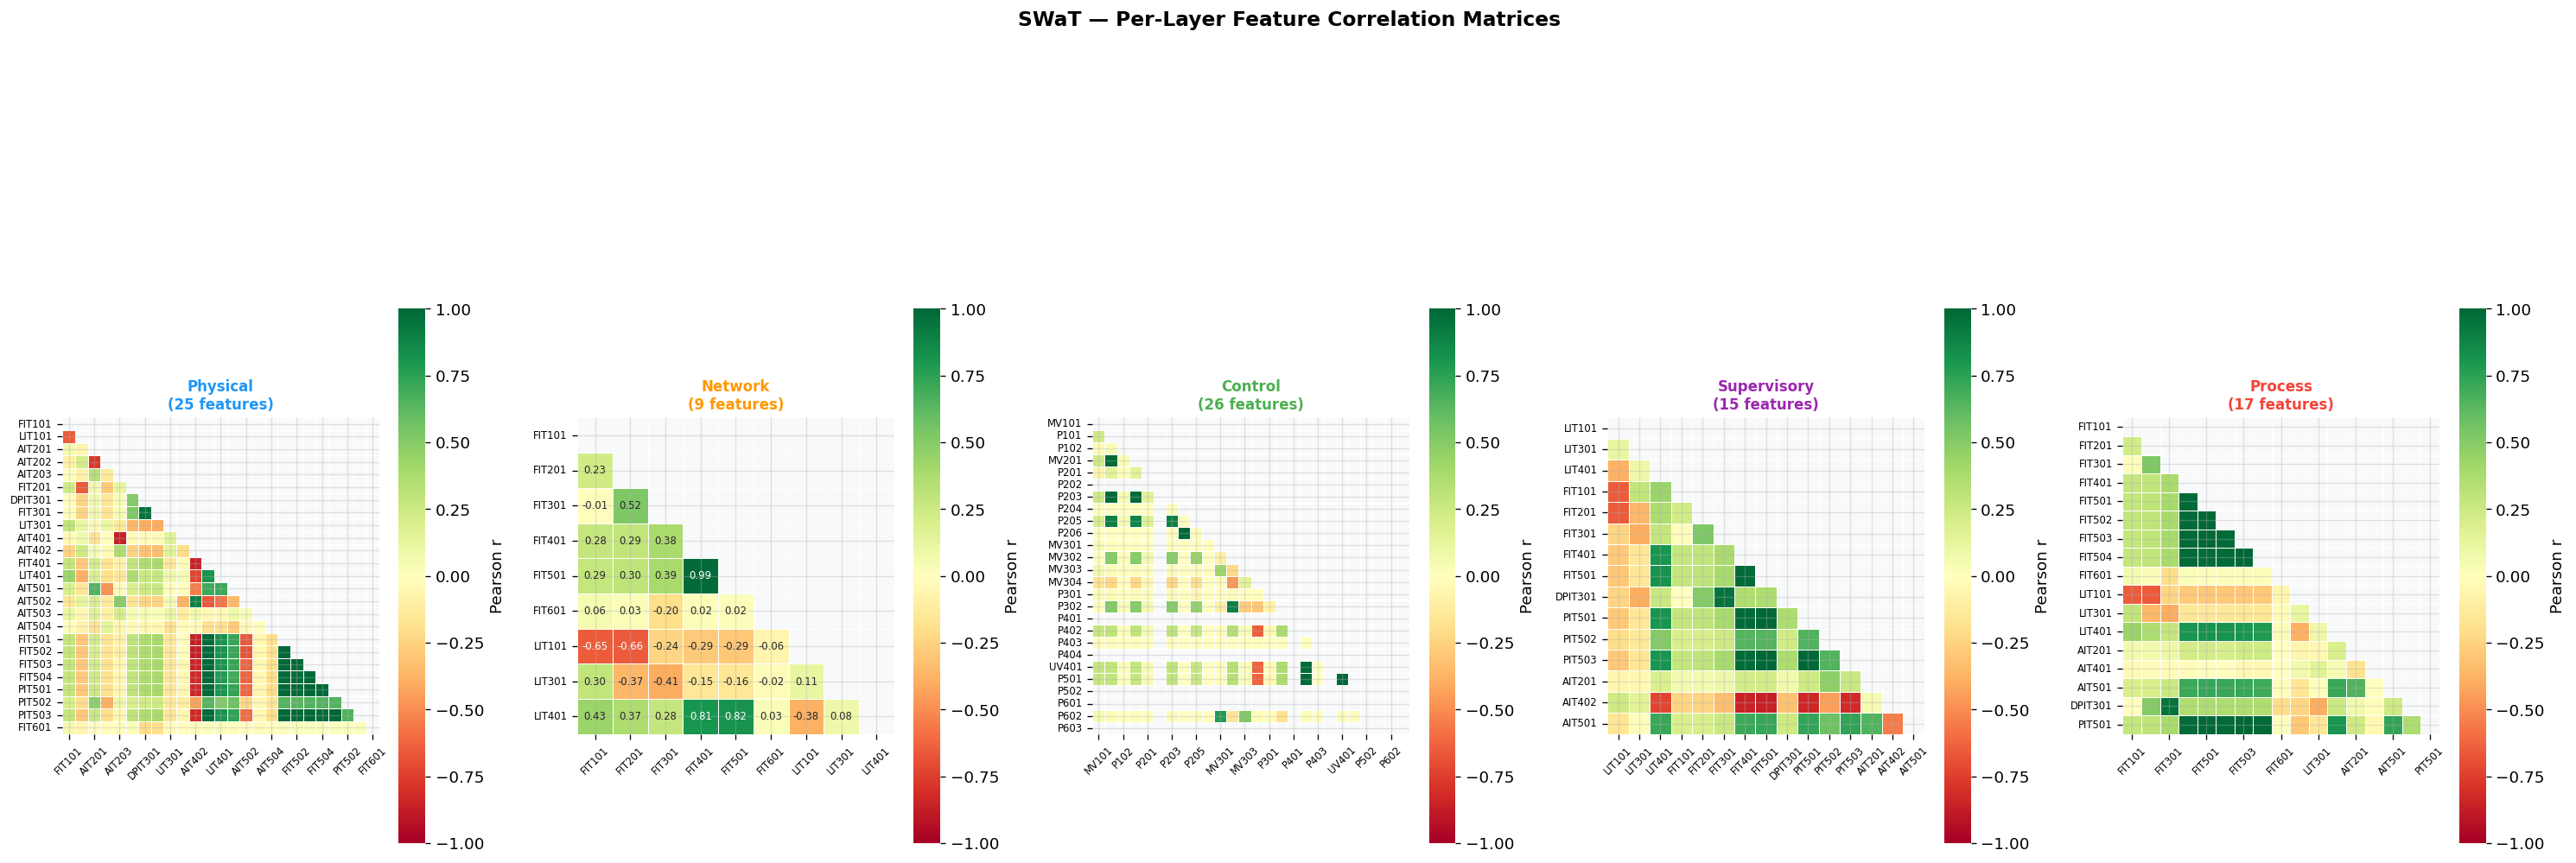

 Saved: 02_correlation_heatmaps.png


In [7]:
active = [(l, list(dict.fromkeys(f)))
          for l, f in LAYER_MAP.items() if f]
n      = len(active)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5*n//3+3))
if n == 1:
    axes = [axes]

fig.suptitle('SWaT — Per-Layer Feature Correlation Matrices',
             fontsize=14, fontweight='bold')

for idx, (layer, feats) in enumerate(active):
    corr = df[feats].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=axes[idx], mask=mask,
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        annot=(len(feats) <= 14), fmt='.2f',
        annot_kws={'size': 7},
        linewidths=0.3, square=True,
        cbar_kws={'shrink': 0.5, 'label': 'Pearson r'}
    )
    axes[idx].set_title(f'{layer.capitalize()}\n({len(feats)} features)',
                         fontweight='bold', color=LAYER_COLORS[layer],
                         fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=7)
    axes[idx].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/02_correlation_heatmaps.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 02_correlation_heatmaps.png')

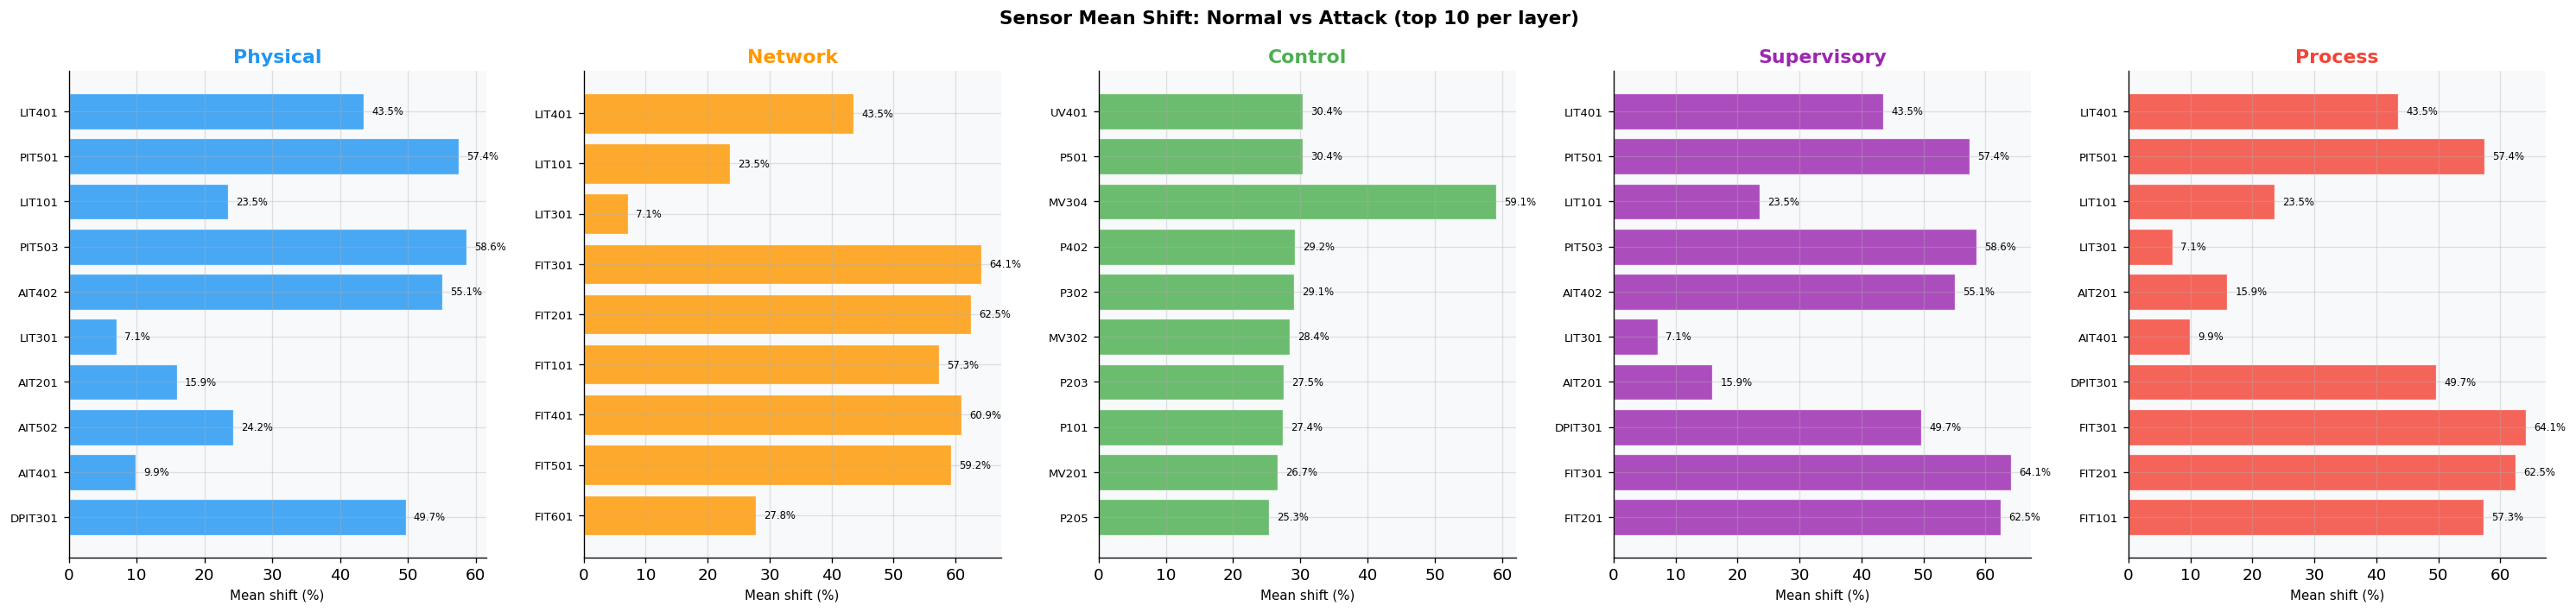

 Saved: 03_mean_shift_per_layer.png


In [8]:
active = [(l, f) for l, f in LAYER_MAP.items()
          if f and l in layer_stats]
n      = len(active)

fig, axes = plt.subplots(1, n, figsize=(5*n, 6))
if n == 1:
    axes = [axes]

fig.suptitle('Sensor Mean Shift: Normal vs Attack (top 10 per layer)',
             fontsize=13, fontweight='bold')

for idx, (layer, _) in enumerate(active):
    stats  = layer_stats[layer]
    top_df = stats.head(min(10, len(stats)))
    color  = LAYER_COLORS[layer]
    vals   = top_df['shift_pct'].values
    max_v  = max(vals) if len(vals) else 1

    bars = axes[idx].barh(range(len(top_df)), vals,
                           color=color, alpha=0.82,
                           edgecolor='white', linewidth=0.8)
    axes[idx].set_yticks(range(len(top_df)))
    axes[idx].set_yticklabels(top_df.index, fontsize=8)
    axes[idx].set_title(f'{layer.capitalize()}',
                         fontweight='bold', color=color)
    axes[idx].set_xlabel('Mean shift (%)', fontsize=9)
    axes[idx].invert_yaxis()
    for bar, val in zip(bars, vals):
        axes[idx].text(val + max_v*0.02,
                       bar.get_y() + bar.get_height()/2,
                       f'{val:.1f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/03_mean_shift_per_layer.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 03_mean_shift_per_layer.png')

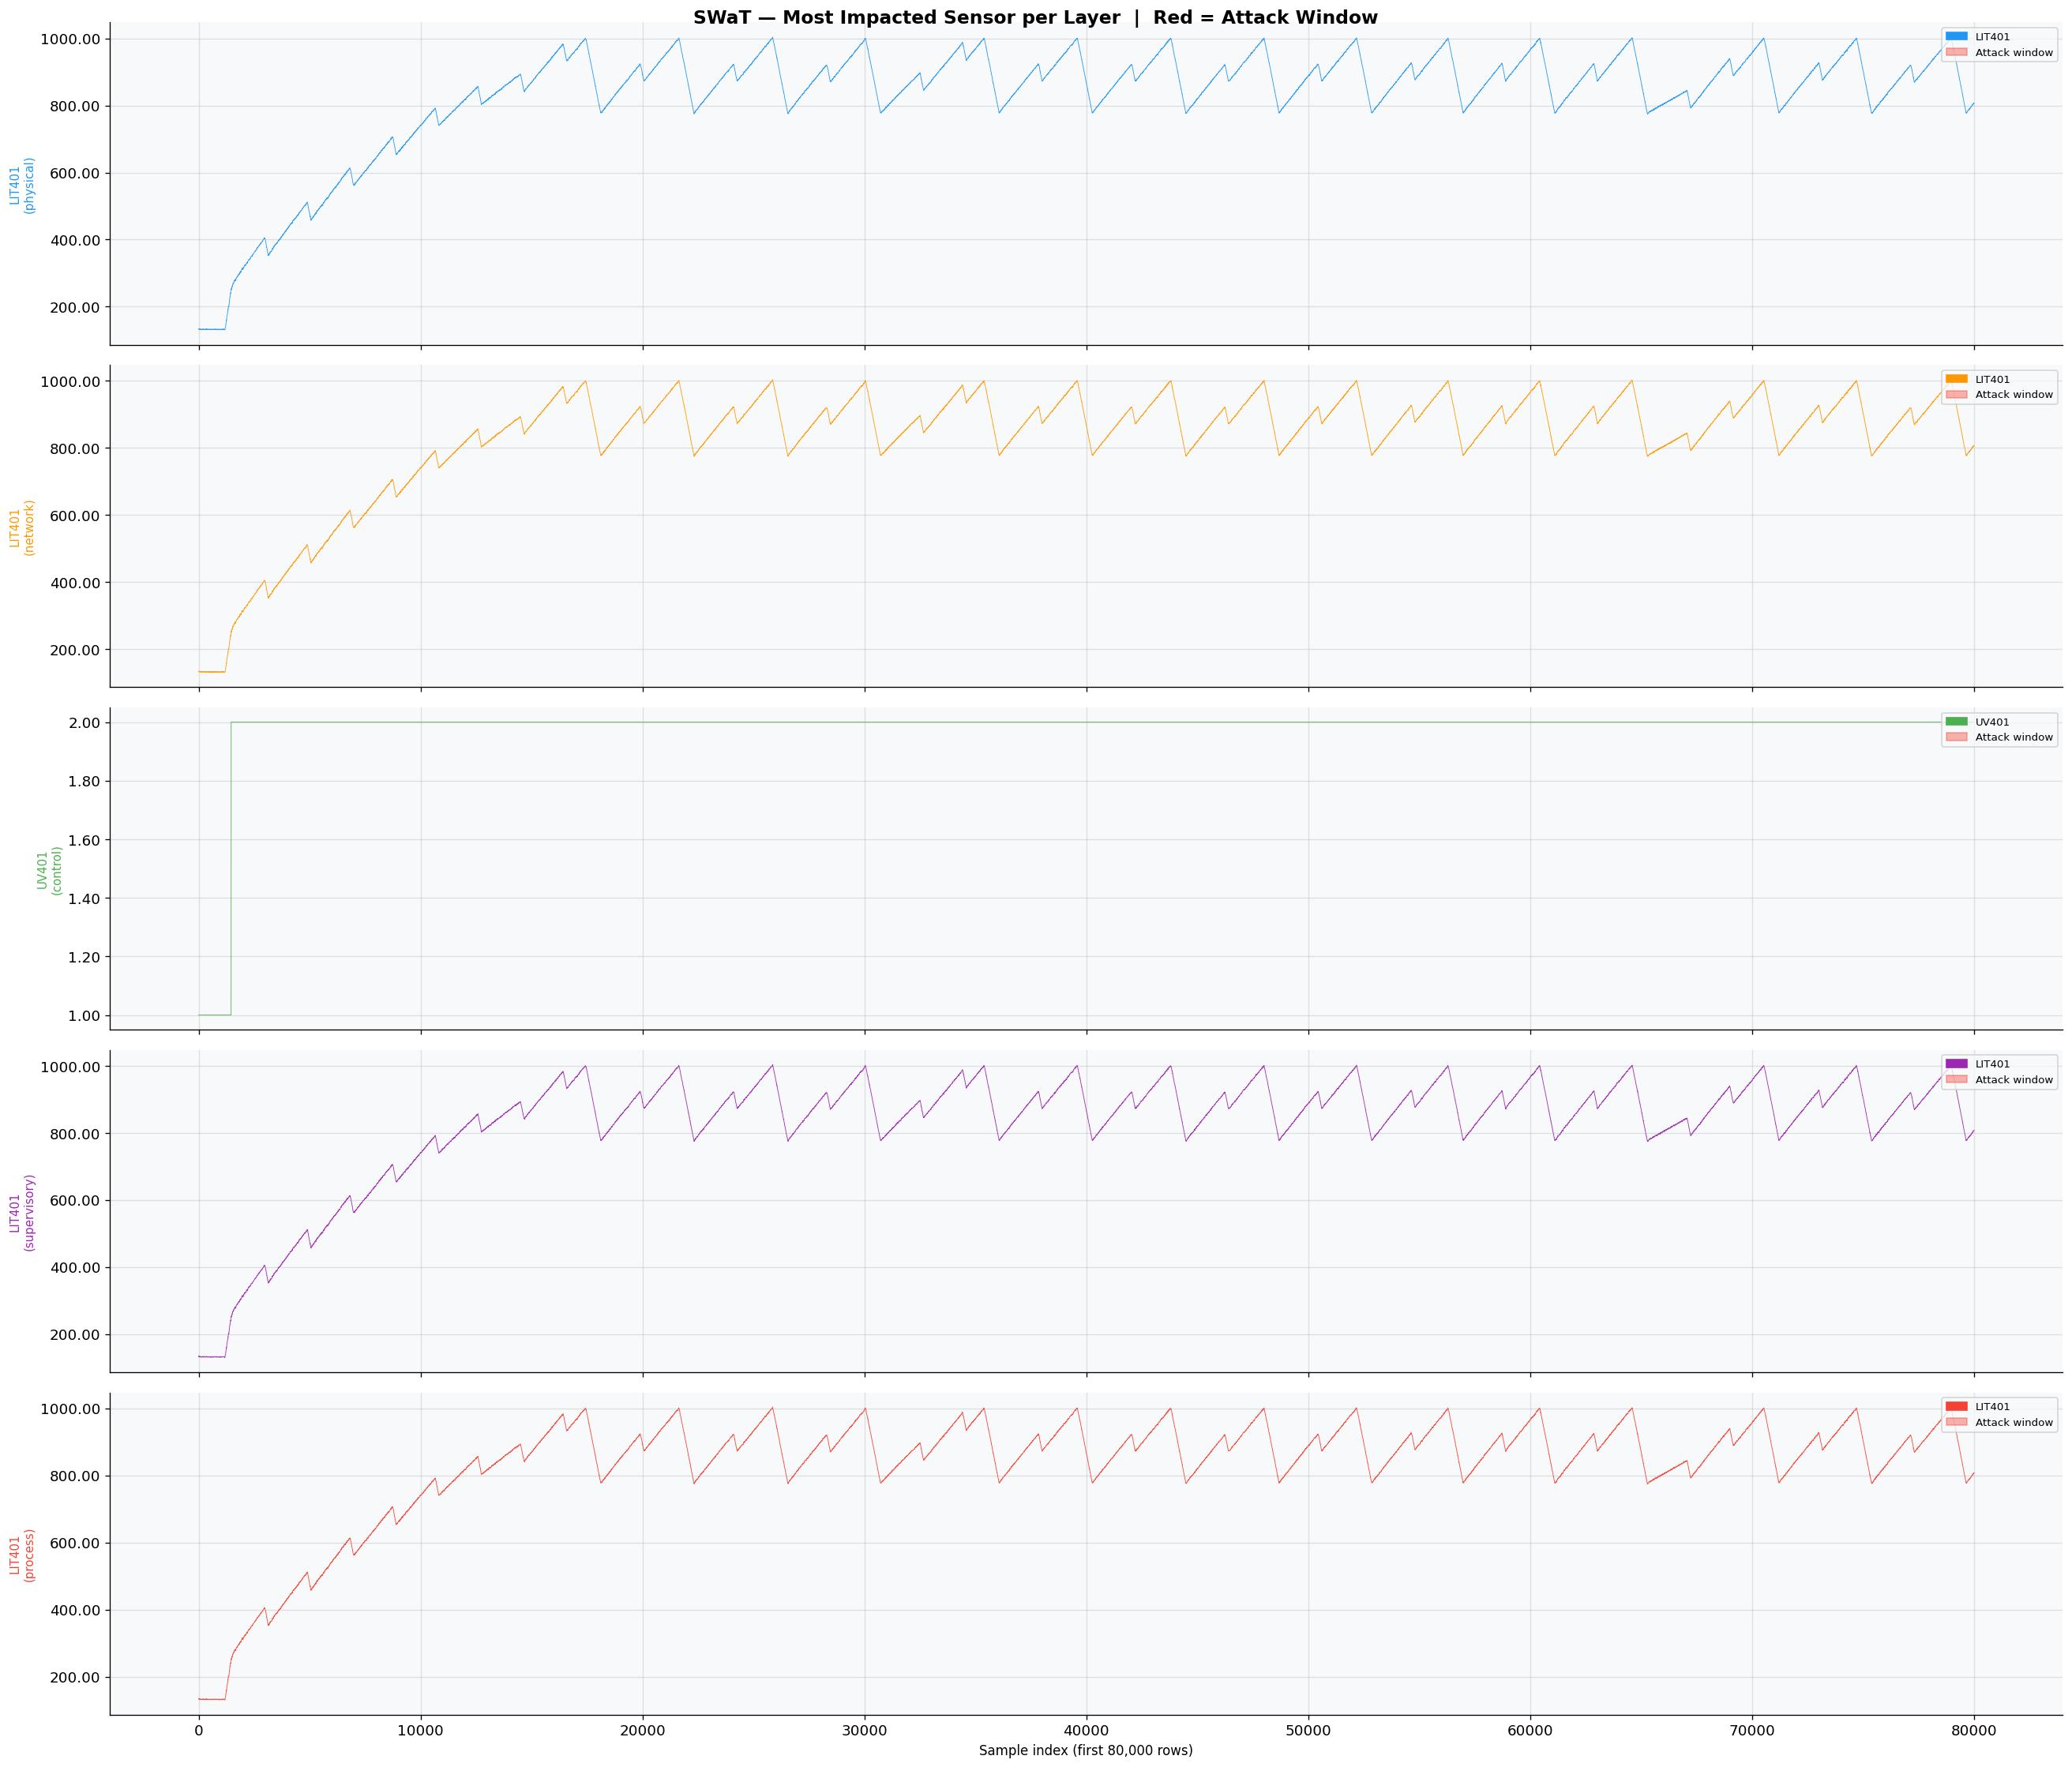

 Saved: 04_timeseries_attack.png


In [9]:
key_sensors = {}
for layer, feats in LAYER_MAP.items():
    if not feats:
        continue
    if layer in layer_stats and not layer_stats[layer].empty:
        top = layer_stats[layer].index[0]
        key_sensors[layer] = top if top in df.columns else feats[0]
    else:
        key_sensors[layer] = feats[0]

active_ks = [(l, s) for l, s in key_sensors.items() if s in df.columns]
N         = min(80_000, len(df))
samp      = df.iloc[:N].copy().reset_index(drop=True)

fig, axes = plt.subplots(len(active_ks), 1,
                          figsize=(22, 3.8*len(active_ks)),
                          sharex=True)
if len(active_ks) == 1:
    axes = [axes]

fig.suptitle('SWaT — Most Impacted Sensor per Layer  |  Red = Attack Window',
             fontsize=14, fontweight='bold')

for idx, (layer, sensor) in enumerate(active_ks):
    color = LAYER_COLORS[layer]
    axes[idx].plot(np.arange(N), samp[sensor].values,
                   color=color, linewidth=0.55, alpha=0.9)

    atk    = samp['binary_label'].values
    in_atk = False
    start  = 0
    for i in range(len(atk)):
        if atk[i] == 1 and not in_atk:
            start  = i
            in_atk = True
        elif atk[i] == 0 and in_atk:
            axes[idx].axvspan(start, i, alpha=0.22, color='#F44336')
            in_atk = False
    if in_atk:
        axes[idx].axvspan(start, len(atk)-1, alpha=0.22, color='#F44336')

    axes[idx].set_ylabel(f'{sensor}\n({layer})', color=color, fontsize=9)
    axes[idx].legend(
        handles=[mpatches.Patch(color=color,     label=sensor),
                 mpatches.Patch(color='#F44336', alpha=0.4,
                                label='Attack window')],
        loc='upper right', fontsize=8)
    axes[idx].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

axes[-1].set_xlabel(f'Sample index (first {N:,} rows)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT}/figures/04_timeseries_attack.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 04_timeseries_attack.png')

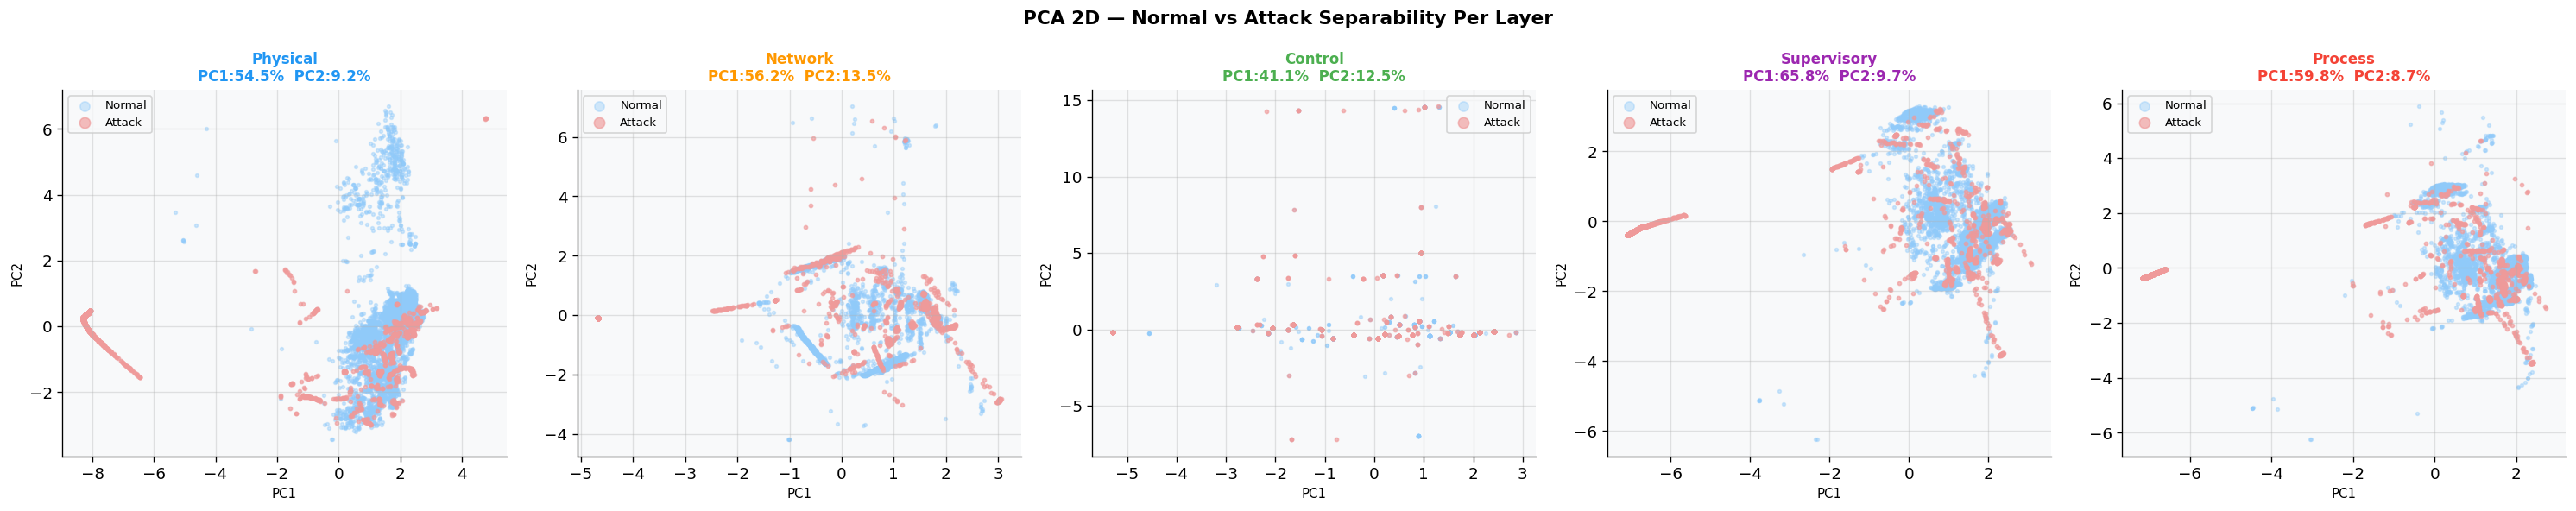

 Saved: 05_pca_per_layer.png


In [10]:
n_atk    = int(df['binary_label'].sum())
s_n      = df[df['binary_label']==0].sample(min(5000, len(df)-n_atk),
                                             random_state=42)
s_a      = df[df['binary_label']==1].sample(min(2000, n_atk),
                                             random_state=42)
samp_pca = pd.concat([s_n, s_a]).reset_index(drop=True)

active = [(l, list(dict.fromkeys(f)))
          for l, f in LAYER_MAP.items() if f]
n      = len(active)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

fig.suptitle('PCA 2D — Normal vs Attack Separability Per Layer',
             fontsize=13, fontweight='bold')

for idx, (layer, feats) in enumerate(active):
    X2    = PCA(n_components=2, random_state=42).fit_transform(
                StandardScaler().fit_transform(samp_pca[feats].values))
    lbls  = samp_pca['binary_label'].values
    color = LAYER_COLORS[layer]
    pca_  = PCA(n_components=2, random_state=42).fit(
                StandardScaler().fit_transform(samp_pca[feats].values))
    ev    = pca_.explained_variance_ratio_ * 100

    axes[idx].scatter(X2[lbls==0,0], X2[lbls==0,1],
                       c='#90CAF9', s=5, alpha=0.4,
                       label='Normal', rasterized=True)
    axes[idx].scatter(X2[lbls==1,0], X2[lbls==1,1],
                       c='#EF9A9A', s=6, alpha=0.65,
                       label='Attack', rasterized=True)
    axes[idx].set_title(
        f'{layer.capitalize()}\nPC1:{ev[0]:.1f}%  PC2:{ev[1]:.1f}%',
        fontsize=10, fontweight='bold', color=color)
    axes[idx].set_xlabel('PC1', fontsize=9)
    axes[idx].set_ylabel('PC2', fontsize=9)
    axes[idx].legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/05_pca_per_layer.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 05_pca_per_layer.png')

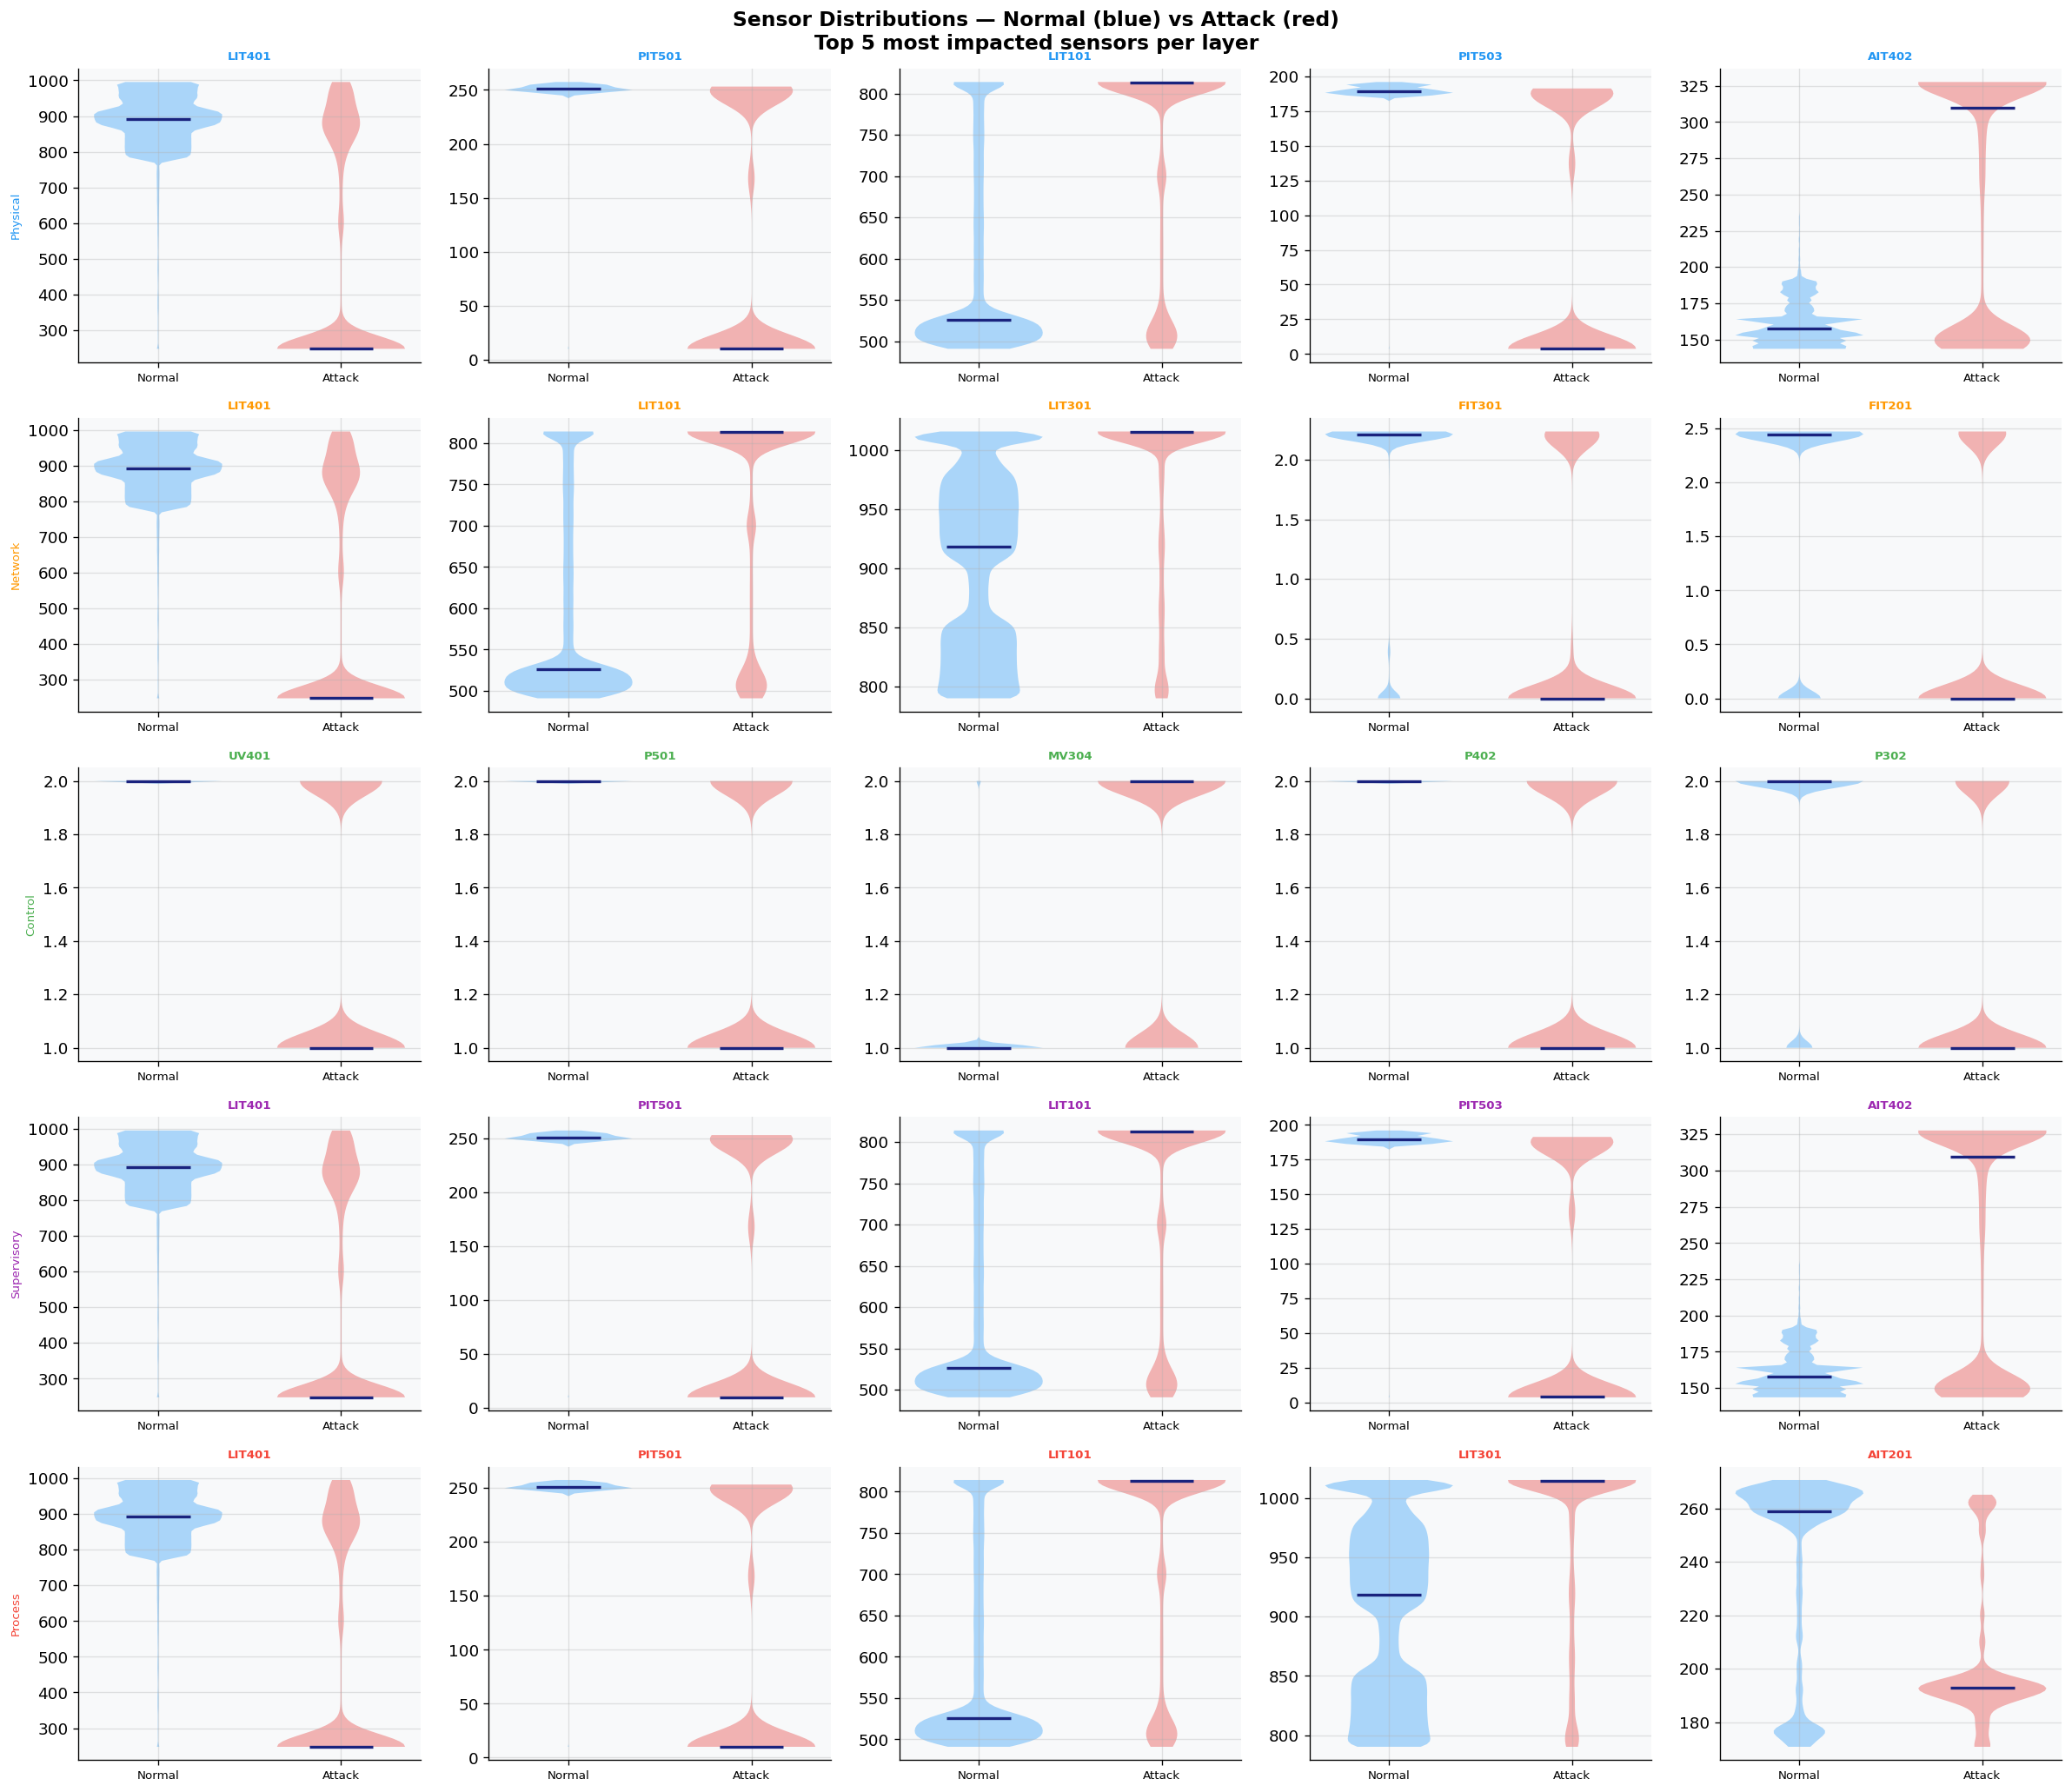

 Saved: 06_violin_distributions.png


In [11]:
TOP_N  = 5
active = [(l, list(dict.fromkeys(f)))
          for l, f in LAYER_MAP.items()
          if f and l in layer_stats]
nr     = len(active)

fig, axes = plt.subplots(nr, TOP_N, figsize=(TOP_N*4, nr*3.5))
if nr == 1:
    axes = np.array([axes])

fig.suptitle('Sensor Distributions — Normal (blue) vs Attack (red)\n'
             'Top 5 most impacted sensors per layer',
             fontsize=14, fontweight='bold')

for ri, (layer, feats) in enumerate(active):
    top_feats = [f for f in layer_stats[layer].index
                 if f in feats][:TOP_N]
    color     = LAYER_COLORS[layer]

    for ci in range(TOP_N):
        ax = axes[ri][ci]
        if ci >= len(top_feats):
            ax.set_visible(False)
            continue

        feat   = top_feats[ci]
        data_n = df[df['binary_label']==0][feat].dropna().values
        data_a = df[df['binary_label']==1][feat].dropna().values

        if len(data_a) < 5:
            ax.set_visible(False)
            continue

        lo = np.percentile(np.concatenate([data_n, data_a]), 2)
        hi = np.percentile(np.concatenate([data_n, data_a]), 98)
        data_n = np.clip(data_n, lo, hi)
        data_a = np.clip(data_a, lo, hi)

        vp = ax.violinplot([data_n, data_a],
                            positions=[0, 1],
                            showmedians=True,
                            showextrema=False,
                            widths=0.7)
        vp['bodies'][0].set_facecolor('#90CAF9')
        vp['bodies'][0].set_alpha(0.75)
        vp['bodies'][1].set_facecolor('#EF9A9A')
        vp['bodies'][1].set_alpha(0.75)
        vp['cmedians'].set_color('#1A237E')
        vp['cmedians'].set_linewidth(2)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Normal', 'Attack'], fontsize=8)
        ax.set_title(feat, fontsize=8, fontweight='bold', color=color)
        if ci == 0:
            ax.set_ylabel(layer.capitalize(), fontsize=8, color=color)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/06_violin_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 06_violin_distributions.png')

In [12]:
P = f'{OUT}/processed'

# 1. Full cleaned dataset
df.to_csv(f'{P}/swat_clean.csv', index=False)
print(f' swat_clean.csv        → {df.shape[0]:,} rows × {df.shape[1]} cols')

# 2. MinMax normalised — model-ready
scaler    = MinMaxScaler()
valid_s   = [c for c in SENSOR_COLS if c in df.columns]
df_scaled = df.copy()
df_scaled[valid_s] = scaler.fit_transform(df[valid_s])
df_scaled.to_csv(f'{P}/swat_scaled.csv', index=False)
print(f' swat_scaled.csv       → MinMax normalised, model-ready')

# 3. Per-layer CSVs
meta = [c for c in ['binary_label', 'label', 'source', TIME_COL]
        if c and c in df.columns]
for layer, feats in LAYER_MAP.items():
    if not feats:
        continue
    unique = list(dict.fromkeys(feats))
    keep_c = unique + [m for m in meta if m not in unique]
    df[keep_c].to_csv(f'{P}/layer_{layer}.csv', index=False)
    print(f' layer_{layer}.csv'
          f'{" "*(14-len(layer))}→ {df.shape[0]:,} rows '
          f'× {len(keep_c)} cols')

# 4. Scaler
with open(f'{P}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f' scaler.pkl            → MinMaxScaler saved')

# 5. Layer stats
with open(f'{P}/layer_stats.pkl', 'wb') as f:
    pickle.dump(layer_stats, f)
print(f' layer_stats.pkl       → per-layer statistics')

# 6. Sensor columns
with open(f'{P}/sensor_cols.json', 'w') as f:
    json.dump(SENSOR_COLS, f, indent=2)
print(f' sensor_cols.json      → {len(SENSOR_COLS)} columns')

# 7. Layer map
with open(f'{P}/layer_map.json', 'w') as f:
    json.dump(LAYER_MAP, f, indent=2)
print(f' layer_map.json        → 5-layer assignments')

# 8. Phase 1 config
config = {
    'dataset'       : 'SWaT A1 & A2 Dec 2015',
    'total_rows'    : len(df),
    'normal_rows'   : int((df['binary_label']==0).sum()),
    'attack_rows'   : int((df['binary_label']==1).sum()),
    'attack_pct'    : round(df['binary_label'].mean()*100, 3),
    'n_sensor_cols' : len(SENSOR_COLS),
    'n_layers'      : 5,
    'time_col'      : TIME_COL,
    'sensor_cols'   : SENSOR_COLS,
    'layer_sizes'   : {l: len(f) for l, f in LAYER_MAP.items()},
}
with open(f'{P}/phase1_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f' phase1_config.json    → config for all phases')

print()
print('  PHASE 1 COMPLETE')
print()
print(f'  Total rows     : {len(df):,}')
print(f'  Normal samples : {(df["binary_label"]==0).sum():,}')
print(f'  Attack samples : {(df["binary_label"]==1).sum():,}')
print(f'  Attack ratio   : {df["binary_label"].mean()*100:.2f}%')
print(f'  Sensor cols    : {len(SENSOR_COLS)}')
print(f'  Layers defined : 5')
print(f'  Figures saved  : 6')
print(f'  Files saved    : 8')
print()
print()

 swat_clean.csv        → 944,919 rows × 55 cols
 swat_scaled.csv       → MinMax normalised, model-ready
 layer_physical.csv      → 944,919 rows × 29 cols
 layer_network.csv       → 944,919 rows × 13 cols
 layer_control.csv       → 944,919 rows × 30 cols
 layer_supervisory.csv   → 944,919 rows × 19 cols
 layer_process.csv       → 944,919 rows × 21 cols
 scaler.pkl            → MinMaxScaler saved
 layer_stats.pkl       → per-layer statistics
 sensor_cols.json      → 51 columns
 layer_map.json        → 5-layer assignments
 phase1_config.json    → config for all phases

  PHASE 1 COMPLETE

  Total rows     : 944,919
  Normal samples : 890,298
  Attack samples : 54,621
  Attack ratio   : 5.78%
  Sensor cols    : 51
  Layers defined : 5
  Figures saved  : 6
  Files saved    : 8


